# Módulo 4 — Segmentación de Carriers
## Clustering con K-Means (aprendizaje no supervisado)

---

### Objetivo de negocio
Agrupar a los carriers (transportistas) en **segmentos con comportamiento similar**,
según su costo, confiabilidad y volumen. El objetivo es pasar de analizar 30 carriers
individualmente a manejar unos pocos **perfiles estratégicos**, facilitando decisiones
de negociación, asignación de carga y gestión de proveedores.

### Pregunta que responde
> *"¿Existen grupos naturales de carriers con perfiles distintos (ej. caros pero
> confiables vs. baratos pero lentos), y cómo deberíamos tratar a cada grupo?"*

### Diferencia fundamental con los módulos anteriores
Los módulos 1-3 usaron **aprendizaje supervisado**: teníamos una variable objetivo
conocida (costo, retraso) y el modelo aprendía a predecirla. Este módulo usa
**aprendizaje NO supervisado**:
- **No hay variable objetivo.** No le decimos al modelo qué buscar.
- El algoritmo **descubre estructura oculta** en los datos por sí mismo.
- No se evalúa con "precisión", sino con métricas de cohesión de grupos.

### Datos utilizados
- **Fuente:** `02_shipments_limpio.csv`, agregado **a nivel de carrier**.
- Construiremos un perfil por carrier con métricas de costo, confiabilidad y volumen.

### Metodología
Se usa **K-Means**, el algoritmo de clustering más común:
- Agrupa los carriers en K grupos, minimizando la distancia dentro de cada grupo.
- Determinaremos el número óptimo de grupos (K) con el **método del codo** y el
  **coeficiente de silueta**.
- Las variables se **escalarán** (StandardScaler), porque K-Means es sensible a la escala.

### Aplicación de negocio
La segmentación permite estrategias diferenciadas por grupo: qué carriers premiar con
más volumen, cuáles renegociar, y cuáles poner en observación.

---


## 1. Construcción del perfil de carriers

Para segmentar carriers, primero necesitamos **describir a cada uno con métricas
resumidas**. Pasamos de 219,120 embarques individuales a una tabla de ~30 filas (una por
carrier), donde cada carrier se caracteriza por su comportamiento.

**Métricas elegidas (las tres dimensiones del negocio):**

- **Costo:** costo promedio por embarque y costo promedio por kg. Refleja qué tan caro
  es el carrier.
- **Confiabilidad:** % de entregas a tiempo y % de embarques dañados. Refleja calidad
  de servicio.
- **Volumen:** número total de embarques y peso total movido. Refleja qué tan
  estratégico es el carrier para la operación.

Estas tres dimensiones (costo, confiabilidad, volumen) son las que un gerente de
logística usa para evaluar proveedores, por lo que los segmentos resultantes serán
directamente accionables.
    

In [1]:
# ============================================================
# MÓDULO 4: SEGMENTACIÓN DE CARRIERS — Clustering K-Means
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Configuración visual
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_palette('deep')

# Cargar datos
df = pd.read_csv('../data/processed/02_shipments_limpio.csv')
print(f"✓ Datos cargados: {df.shape[0]:,} embarques")

# ---- Construir perfil por carrier ----
perfil = df.groupby('carrier_id').agg(
    costo_prom_embarque=('total_cost_usd', 'mean'),
    costo_prom_kg=('total_cost_usd', 'sum'),          # se ajustará abajo
    peso_total=('chargeable_weight_kg', 'sum'),
    pct_a_tiempo=('on_time_delivery_flag', 'mean'),
    pct_danados=('damaged_flag', 'mean'),
    num_embarques=('shipment_id', 'count')
).reset_index()

# Calcular costo por kg correctamente (costo total / peso total)
perfil['costo_prom_kg'] = perfil['costo_prom_kg'] / perfil['peso_total']

# Convertir porcentajes a escala 0-100 para legibilidad
perfil['pct_a_tiempo'] = perfil['pct_a_tiempo'] * 100
perfil['pct_danados'] = perfil['pct_danados'] * 100

print(f"✓ Perfil construido: {len(perfil)} carriers")
print()
print("Vista del perfil de carriers:")
print(perfil.round(2).to_string(index=False))

✓ Datos cargados: 219,120 embarques
✓ Perfil construido: 30 carriers

Vista del perfil de carriers:
carrier_id  costo_prom_embarque  costo_prom_kg  peso_total  pct_a_tiempo  pct_danados  num_embarques
      C001              4290.29           0.37  73272711.1         86.31         1.24           6353
      C002              4080.15           0.35  42966515.3         88.59         1.26           3726
      C003              4353.21           0.38 214795438.0         85.80         1.62          18612
      C004              4471.38           0.39  61116654.0         88.84         1.32           5286
      C005              3809.41           0.33  11332264.5         79.59         1.73            980
      C006              3649.13           0.32  65316338.2         74.71         2.02           5655
      C007              3815.91           0.33   9432870.2         82.46         1.83            821
      C008              3722.83           0.34    694264.3         76.19         3.17       

## 2. Selección de variables y escalado

Seleccionamos las variables que definen el perfil de cada carrier y las **escalamos**.

**¿Por qué escalar es OBLIGATORIO en K-Means?**
K-Means agrupa según **distancias** entre puntos. Nuestras variables tienen escalas
radicalmente distintas:
- `peso_total`: cientos de millones (ej. 214,795,438)
- `pct_danados`: valores de 1 a 4

Sin escalar, la variable de mayor magnitud (peso) **dominaría por completo** el cálculo
de distancias, y K-Means ignoraría la confiabilidad y el costo. El escalado
(StandardScaler) pone todas las variables en la misma escala (media 0, desviación 1),
para que cada una contribuya equitativamente.

**Variables seleccionadas para el clustering:**
- `costo_prom_embarque`, `costo_prom_kg` (dimensión costo)
- `pct_a_tiempo`, `pct_danados` (dimensión confiabilidad)
- `num_embarques`, `peso_total` (dimensión volumen)

In [2]:
# ============================================================
# Seleccionar variables y escalar
# ============================================================

# Variables para el clustering (las 6 métricas del perfil)
vars_cluster = ['costo_prom_embarque', 'costo_prom_kg',
                'pct_a_tiempo', 'pct_danados',
                'num_embarques', 'peso_total']

# Extraer la matriz de datos (sin el carrier_id, que es solo etiqueta)
X_cluster = perfil[vars_cluster].copy()

# Escalar: media 0, desviación estándar 1
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X_cluster)

print("✓ Variables seleccionadas:", len(vars_cluster))
print("✓ Datos escalados (media≈0, desv≈1)")
print()
print("Comparación de escalas ANTES de escalar:")
print(X_cluster.describe().round(2).loc[['mean', 'std']].to_string())
print()
print("Después de escalar (todas centradas en 0, desv 1):")
print(pd.DataFrame(X_escalado, columns=vars_cluster).describe().round(2).loc[['mean', 'std']].to_string())

✓ Variables seleccionadas: 6
✓ Datos escalados (media≈0, desv≈1)

Comparación de escalas ANTES de escalar:
      costo_prom_embarque  costo_prom_kg  pct_a_tiempo  pct_danados  num_embarques   peso_total
mean              2796.67           4.94         80.57         1.60        7304.00  31053349.11
std               1743.91           6.83          8.62         0.79        6965.74  57915048.97

Después de escalar (todas centradas en 0, desv 1):
      costo_prom_embarque  costo_prom_kg  pct_a_tiempo  pct_danados  num_embarques  peso_total
mean                 0.00           0.00         -0.00        -0.00          -0.00       -0.00
std                  1.02           1.02          1.02         1.02           1.02        1.02


## 3. Determinación del número óptimo de grupos (K)

En K-Means, **nosotros elegimos cuántos grupos (K) queremos**. Pero elegir K al azar
sería arbitrario. Usamos dos métodos objetivos para encontrar el número óptimo:

**1. Método del codo (Elbow Method):**
Medimos la "inercia" (qué tan compactos son los grupos) para distintos valores de K.
A más grupos, menor inercia — pero llega un punto donde agregar grupos ya casi no mejora.
Ese punto de "quiebre" (el codo) sugiere el K óptimo: el balance entre simplicidad y ajuste.

**2. Coeficiente de silueta (Silhouette Score):**
Mide qué tan bien separado está cada punto de los grupos vecinos, en un rango de -1 a 1.
Más alto = grupos mejor definidos. Buscamos el K que maximice esta métrica.

Probamos K de 2 a 8 y comparamos ambos métodos para decidir con criterio.

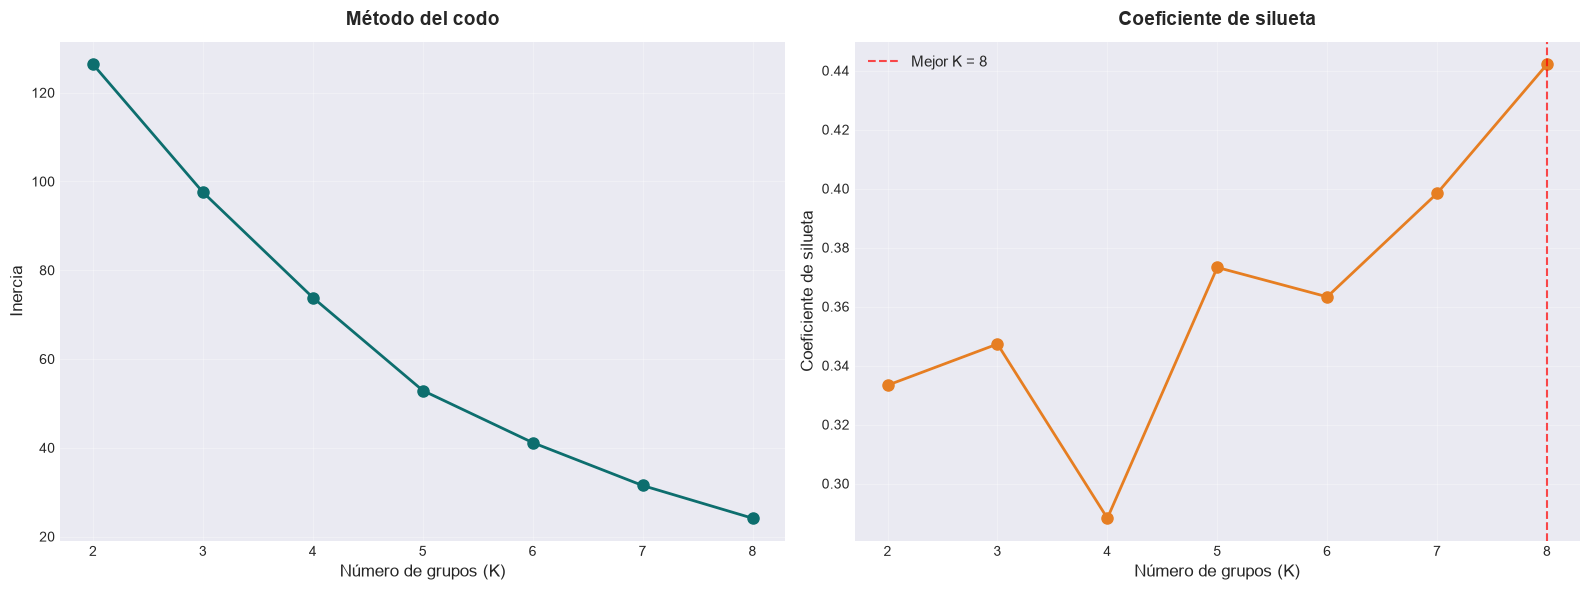

Resumen por número de grupos:
  K      Inercia    Silueta
  2       126.38     0.3333
  3        97.56     0.3473
  4        73.83     0.2882
  5        52.89     0.3733
  6        41.16     0.3633
  7        31.50     0.3984
  8        24.12     0.4421

→ Mejor K según silueta: 8 (silueta = 0.4421)


In [3]:
# ============================================================
# Buscar el número óptimo de grupos (K)
# ============================================================

# Rango de K a probar
rango_k = range(2, 9)

inercias = []
siluetas = []

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_escalado)

    inercias.append(km.inertia_)
    siluetas.append(silhouette_score(X_escalado, labels))

# Graficar ambos métodos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Método del codo
axes[0].plot(list(rango_k), inercias, marker='o', linewidth=2,
             markersize=8, color='#0D6E6E')
axes[0].set_xlabel('Número de grupos (K)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método del codo', fontsize=14, fontweight='bold', pad=12)
axes[0].grid(True, alpha=0.3)

# Coeficiente de silueta
axes[1].plot(list(rango_k), siluetas, marker='o', linewidth=2,
             markersize=8, color='#E67E22')
axes[1].set_xlabel('Número de grupos (K)', fontsize=12)
axes[1].set_ylabel('Coeficiente de silueta', fontsize=12)
axes[1].set_title('Coeficiente de silueta', fontsize=14, fontweight='bold', pad=12)
axes[1].grid(True, alpha=0.3)

# Marcar el mejor K según silueta
mejor_k = list(rango_k)[np.argmax(siluetas)]
axes[1].axvline(x=mejor_k, color='red', linestyle='--', alpha=0.7,
                label=f'Mejor K = {mejor_k}')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

# Tabla resumen
print("Resumen por número de grupos:")
print(f"{'K':>3} {'Inercia':>12} {'Silueta':>10}")
for k, inr, sil in zip(rango_k, inercias, siluetas):
    print(f"{k:>3} {inr:>12.2f} {sil:>10.4f}")
print()
print(f"→ Mejor K según silueta: {mejor_k} (silueta = {max(siluetas):.4f})")

### Decisión sobre el número de grupos: K=4

Los métodos arrojan resultados que debemos interpretar con **criterio de negocio**, no
solo matemático:

- **Silueta:** sugiere K=8 (0.4421) como óptimo puramente estadístico.
- **Método del codo:** muestra un quiebre claro alrededor de **K=4**, donde la reducción
  de inercia empieza a desacelerarse.

**¿Por qué elegimos K=4 y no K=8?**

Con solo **30 carriers**, dividir en 8 grupos produciría segmentos de ~3-4 carriers cada
uno: demasiado fragmentado para ser **accionable**. Una empresa no puede gestionar 8
estrategias de proveedor distintas para 30 transportistas de forma práctica.

**K=4 ofrece el mejor balance:**
- Suficientes grupos para capturar perfiles claramente diferenciados (premium, económico,
  problemático, estratégico).
- Pocos grupos para que cada segmento sea manejable y tenga una estrategia clara.
- Coincide con el "codo" del método de inercia.

Esta es una decisión donde el **valor de negocio prevalece sobre la métrica estadística
pura**: el "mejor" modelo no es el de mayor silueta, sino el más útil para decidir.
Sobre-segmentar (K=8) daría grupos estadísticamente compactos pero inútiles en la práctica.

## 4. Clustering final con K=4

Entrenamos el modelo K-Means definitivo con 4 grupos y asignamos cada carrier a su
segmento. Luego analizamos el perfil promedio de cada grupo para **interpretarlos y
darles nombre** según su comportamiento.

El paso de **nombrar los grupos** es esencial: K-Means solo entrega números (grupo 0, 1,
2, 3). Convertir esos números en perfiles con significado de negocio (ej. "Premium
confiable") es lo que hace útil el análisis.

In [4]:
# ============================================================
# Clustering final con K=4
# ============================================================

# Entrenar K-Means con 4 grupos
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
perfil['grupo'] = kmeans_final.fit_predict(X_escalado)

# Calcular el perfil promedio de cada grupo
resumen_grupos = perfil.groupby('grupo').agg(
    n_carriers=('carrier_id', 'count'),
    costo_prom_embarque=('costo_prom_embarque', 'mean'),
    costo_prom_kg=('costo_prom_kg', 'mean'),
    pct_a_tiempo=('pct_a_tiempo', 'mean'),
    pct_danados=('pct_danados', 'mean'),
    num_embarques=('num_embarques', 'mean'),
    peso_total=('peso_total', 'mean')
).round(2)

print("=" * 70)
print("PERFIL PROMEDIO DE CADA GRUPO")
print("=" * 70)
print(resumen_grupos.to_string())
print()

# Ver qué carriers cayeron en cada grupo
print("=" * 70)
print("CARRIERS POR GRUPO")
print("=" * 70)
for g in sorted(perfil['grupo'].unique()):
    carriers_g = perfil[perfil['grupo'] == g]['carrier_id'].tolist()
    print(f"Grupo {g} ({len(carriers_g)} carriers): {', '.join(carriers_g)}")

PERFIL PROMEDIO DE CADA GRUPO
       n_carriers  costo_prom_embarque  costo_prom_kg  pct_a_tiempo  pct_danados  num_embarques    peso_total
grupo                                                                                                        
0               9              3521.94           0.53         70.71         1.87        1938.44  1.557517e+07
1               6               298.65          16.97         85.47         1.98       13976.00  2.468060e+05
2               2              4601.72           0.34         76.72         1.43       16462.00  2.194926e+08
3              13              3169.79           3.16         85.74         1.26        6530.31  2.699676e+07

CARRIERS POR GRUPO
Grupo 0 (9 carriers): C005, C006, C008, C013, C014, C026, C027, C028, C030
Grupo 1 (6 carriers): C016, C017, C018, C019, C020, C021
Grupo 2 (2 carriers): C003, C025
Grupo 3 (13 carriers): C001, C002, C004, C007, C009, C010, C011, C012, C015, C022, C023, C024, C029


### Interpretación y nombrado de los segmentos

Los 4 grupos emergen claramente diferenciados. Les asignamos nombres según su perfil:

**Grupo 0 — "Problemáticos / Baja confiabilidad" (9 carriers)**
- Puntualidad más baja (**70.7% a tiempo**) y mayor tasa de daños (1.87%).
- Costo medio-alto sin justificarlo con buen servicio.
- Incluye C026, C027, C028 (los de peor desempeño individual).
- **Estrategia:** vigilancia estrecha, plan de mejora o reemplazo.

**Grupo 1 — "Paquetería ligera (Parcel)" (6 carriers)**
- Costo bajo por embarque (\$299) pero muy alto por kg (\$16.97): carga ligera.
- Altísimo volumen de embarques (13,976 en promedio). Buena puntualidad (85.5%).
- **Estrategia:** ideal para envíos pequeños/urgentes; monitorear costo por kg.

**Grupo 2 — "Gigantes de carga pesada" (2 carriers)**
- Mueven un volumen de peso enorme (219 millones de kg promedio).
- Muy económicos por kg (\$0.34). Puntualidad regular (76.7%).
- **Estrategia:** socios estratégicos para carga masiva; mejorar su puntualidad.

**Grupo 3 — "Confiables estándar / Núcleo operativo" (13 carriers)**
- Mejor puntualidad (**85.7%**) y menor daño (1.26%). Perfil equilibrado.
- El grupo más numeroso: la columna vertebral de la operación.
- **Estrategia:** proveedores preferentes; asignarles el mayor volumen de carga crítica.

**Valor del análisis:** de 30 carriers individuales pasamos a 4 perfiles accionables, cada
uno con una estrategia de gestión clara y diferenciada.

## 5. Visualización de los segmentos

Presentamos dos visualizaciones complementarias:

1. **Mapa de calor (heatmap) de perfiles:** muestra el valor promedio de cada métrica
   por grupo, permitiendo comparar los perfiles de un vistazo. Los colores revelan qué
   distingue a cada segmento.

2. **Visualización 2D con PCA:** como tenemos 6 variables (imposible de graficar en 6
   dimensiones), usamos **PCA (Análisis de Componentes Principales)** para reducir a 2
   dimensiones y ver visualmente cómo se separan los grupos. PCA condensa la información
   de las 6 variables en 2 ejes que capturan la mayor variación posible.

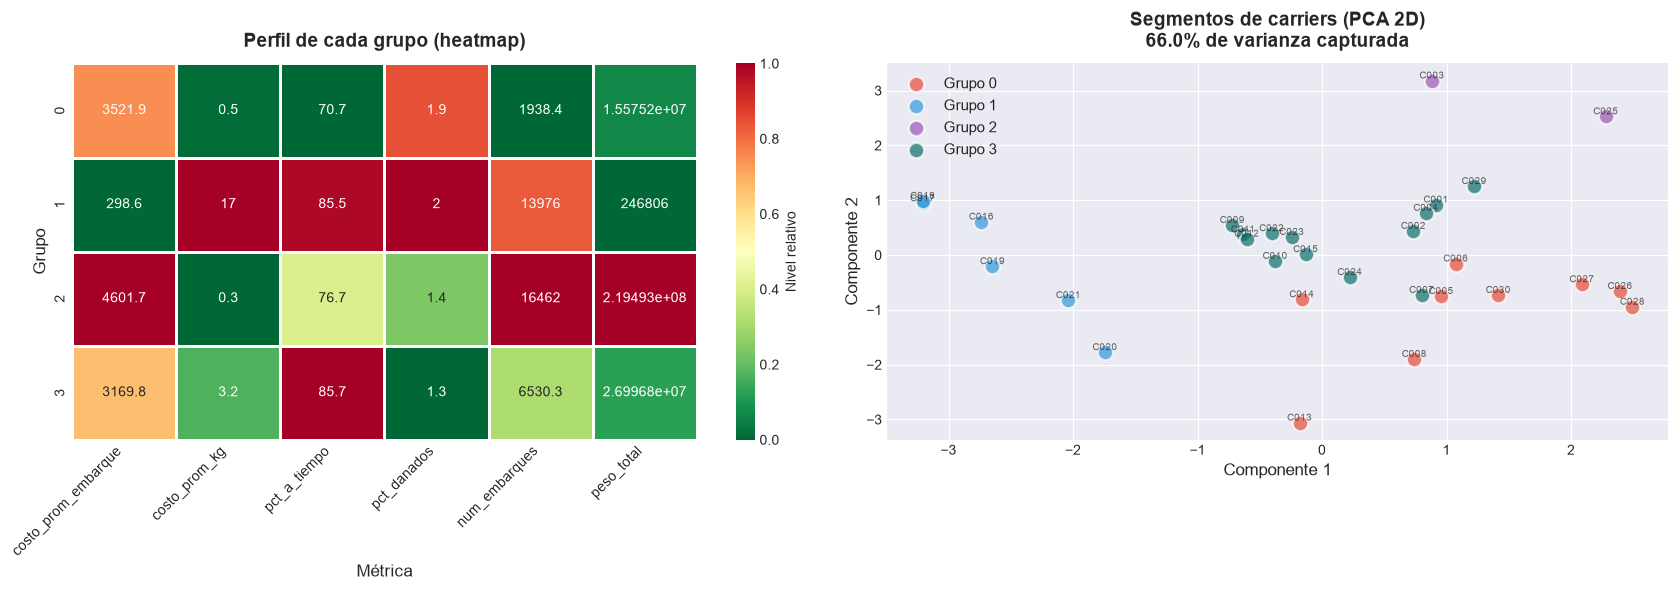

✓ Visualizaciones generadas
✓ PCA captura 66.0% de la información en 2 dimensiones


In [5]:
# ============================================================
# Visualización de los segmentos
# ============================================================

from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ---- Gráfica 1: Heatmap de perfiles por grupo ----
# Normalizamos cada métrica (0-1) para comparar en el mismo mapa de color
heatmap_data = resumen_grupos[['costo_prom_embarque', 'costo_prom_kg',
                                 'pct_a_tiempo', 'pct_danados',
                                 'num_embarques', 'peso_total']].copy()
# Normalizar cada columna a escala 0-1
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

sns.heatmap(heatmap_norm, annot=heatmap_data.round(1), fmt='g',
            cmap='RdYlGn_r', ax=axes[0], cbar_kws={'label': 'Nivel relativo'},
            linewidths=1, linecolor='white')
axes[0].set_title('Perfil de cada grupo (heatmap)', fontsize=14, fontweight='bold', pad=12)
axes[0].set_ylabel('Grupo', fontsize=12)
axes[0].set_xlabel('Métrica', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# ---- Gráfica 2: Visualización 2D con PCA ----
pca = PCA(n_components=2)
coords = pca.fit_transform(X_escalado)

colores_grupo = ['#E74C3C', '#3498DB', '#9B59B6', '#0D6E6E']
for g in sorted(perfil['grupo'].unique()):
    mask = perfil['grupo'] == g
    axes[1].scatter(coords[mask, 0], coords[mask, 1],
                    c=colores_grupo[g], label=f'Grupo {g}',
                    s=120, alpha=0.7, edgecolors='white', linewidth=1.5)

# Etiquetar cada punto con el carrier_id
for i, carrier in enumerate(perfil['carrier_id']):
    axes[1].annotate(carrier, (coords[i, 0], coords[i, 1]),
                     fontsize=7, alpha=0.7, ha='center', va='bottom')

var_exp = pca.explained_variance_ratio_.sum() * 100
axes[1].set_xlabel(f'Componente 1', fontsize=12)
axes[1].set_ylabel(f'Componente 2', fontsize=12)
axes[1].set_title(f'Segmentos de carriers (PCA 2D)\n{var_exp:.1f}% de varianza capturada',
                  fontsize=14, fontweight='bold', pad=12)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("✓ Visualizaciones generadas")
print(f"✓ PCA captura {var_exp:.1f}% de la información en 2 dimensiones")

### Interpretación de las visualizaciones

**Heatmap de perfiles:**
El mapa de calor confirma visualmente la "firma" distintiva de cada grupo:
- **Grupo 1 (Parcel):** destaca en rojo en costo por kg (17) y volumen de embarques
  (13,976), confirmando su naturaleza de paquetería ligera de alto volumen.
- **Grupo 2 (Gigantes):** rojo intenso en peso total (219M kg) y costo por embarque,
  confirmando su rol en carga pesada masiva.
- **Grupo 0 (Problemáticos):** su puntualidad (70.7%) resalta como la más baja del panel.
- **Grupo 3 (Núcleo):** verde en daños y buena puntualidad, perfil equilibrado y confiable.

**Proyección PCA 2D:**
La reducción a 2 dimensiones captura el **66% de la varianza** total, suficiente para
visualizar la separación. Los segmentos con perfiles extremos (Grupo 1 y Grupo 2)
aparecen bien aislados. Los grupos 0 y 3 se solapan parcialmente en el centro, ya que
comparten rangos de costo similares y se diferencian principalmente por confiabilidad
(una dimensión que el plano 2D no alcanza a separar completamente).

## 6. Conclusiones de negocio

### Resumen del análisis
Mediante clustering K-Means (aprendizaje no supervisado), se segmentaron los 30 carriers
en **4 grupos estratégicos** con perfiles claramente diferenciados por costo,
confiabilidad y volumen. El número de grupos se eligió balanceando criterio estadístico
(método del codo) y utilidad de negocio.

### Los 4 segmentos y su estrategia

| Grupo | Perfil | Carriers | Estrategia recomendada |
|-------|--------|----------|------------------------|
| 3 | **Núcleo confiable** | 13 | Proveedores preferentes. Asignar el mayor volumen de carga crítica. |
| 1 | **Paquetería ligera** | 6 | Ideal para envíos pequeños/urgentes. Vigilar costo por kg. |
| 0 | **Problemáticos** | 9 | Vigilancia estrecha. Plan de mejora o reemplazo por baja puntualidad. |
| 2 | **Gigantes de carga** | 2 | Socios estratégicos para carga masiva. Trabajar en su puntualidad. |

### Valor para el negocio

**1. Gestión diferenciada de proveedores.**
En lugar de tratar a 30 carriers por igual, la empresa puede aplicar 4 estrategias
distintas y enfocadas, optimizando la relación con cada tipo de proveedor.

**2. Identificación objetiva de carriers problemáticos.**
El Grupo 0 concentra a los transportistas de peor desempeño (puntualidad de 70.7%),
respaldando con datos las decisiones de renegociación o reemplazo. Esto complementa el
scorecard de carriers del análisis de negocio.

**3. Asignación inteligente de carga.**
Conocer las fortalezas de cada grupo permite dirigir cada tipo de embarque al segmento
más adecuado: carga crítica al núcleo confiable, paquetería al grupo de parcel, carga
masiva a los gigantes.

**4. Base para negociación.**
Los segmentos dan poder de negociación: se puede premiar con más volumen a los confiables
y condicionar la continuidad de los problemáticos a mejoras medibles.

### Limitaciones y siguientes pasos
- La segmentación refleja el comportamiento histórico; debe **actualizarse periódicamente**
  conforme cambie el desempeño de los carriers.
- Con más carriers en el futuro, podría reevaluarse un número mayor de grupos.
- Se recomienda cruzar estos segmentos con el modelo de costos (Módulo 2) para detectar
  qué grupos concentran más anomalías de sobrecosto.

---
*Módulo 4 completado. Segmentación estratégica de carriers lista para la toma de decisiones.*